In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, accuracy_score, classification_report)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19, InceptionV3
from tensorflow.keras.optimizers import Adam
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Dataset paths
TRAIN_DIR = "/content/drive/MyDrive/Colab Notebooks/Jute_Pest_Dataset_Split/train"
VALID_DIR = "/content/drive/MyDrive/Colab Notebooks/Jute_Pest_Dataset_Split/val"
TEST_DIR = "/content/drive/MyDrive/Colab Notebooks/Jute_Pest_Dataset_Split/test"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 0.001


In [4]:
# Data generators with augmentation (following the research paper)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")
print(f"Class indices: {train_generator.class_indices}")


Found 5005 images belonging to 17 classes.
Found 1073 images belonging to 17 classes.
Found 1102 images belonging to 17 classes.
Number of classes: 17
Class indices: {'Beet Armyworm': 0, 'Black Hairy': 1, 'Cutworm': 2, 'Field Cricket': 3, 'Jute Aphid': 4, 'Jute Hairy': 5, 'Jute Red Mite': 6, 'Jute Semilooper': 7, 'Jute Stem Girdler': 8, 'Jute Stem Weevil': 9, 'Leaf Beetle': 10, 'Mealybug': 11, 'Pod Borer': 12, 'Scopula Emissaria': 13, 'Termite': 14, 'Termite odontotermes (Rambur)': 15, 'Yellow Mite': 16}


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet201

IMG_SIZE = 224
num_classes = 17

def build_pretrained_model(base_model, num_classes, model_name):

    # Freeze base model layers
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name=model_name)

    return model

print("Loading Pre-trained Models...")
print("="*70)

# DenseNet201 Model

densenet_base = DenseNet201(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
densenet_model = build_pretrained_model(densenet_base, num_classes, 'DenseNet201')

print("DenseNet201 model built successfully.")
densenet_model.summary()

Loading Pre-trained Models...
DenseNet201 model built successfully.


Model: "DenseNet201"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │        32,657 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,354,641 (70.02 MB)

 Trainable params: 32,657 (127.57 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [10]:
# Compile Model
optimizer = Adam(learning_rate=LEARNING_RATE)
loss_fn = tf.keras.losses.CategoricalCrossentropy()

# DenseNet201
densenet_model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

print("\n" + "="*70)
print("Model Summaries")
print("="*70)
print("\nDenseNet201:")
densenet_model.summary()


Model Summaries

DenseNet201:


Model: "DenseNet201"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │        32,657 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,354,641 (70.02 MB)

 Trainable params: 32,657 (127.57 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [11]:
import os

checkpoint_dir = '/content/drive/MyDrive/Colab Notebooks/checkpoints'

# Create directory for checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"✓ Checkpoint directory ready: {checkpoint_dir}")

# Callbacks for DenseNet201
densenet_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

densenet_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    mode='max',
    min_lr=1e-7,
    verbose=1
)

densenet_checkpoint = keras.callbacks.ModelCheckpoint(
    os.path.join(checkpoint_dir, 'densenet201_last_model.h5'),
    monitor='val_accuracy',
    save_best_only=False, # Save the model at the end of training regardless of performance
    mode='max',
    verbose=1
)

densenet_callbacks = [densenet_early_stopping, densenet_reduce_lr, densenet_checkpoint]

print("✓ Callbacks configured successfully for DenseNet201")


✓ Checkpoint directory ready: /content/drive/MyDrive/Colab Notebooks/checkpoints
✓ Callbacks configured successfully for DenseNet201


In [12]:
print("\n" + "="*70)
print("Training Pre-trained Models...")
print("="*70)

# Train DenseNet201
print("\nTraining DenseNet201...")
densenet_history = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=densenet_callbacks, # Using the callbacks configured in the previous step
    verbose=1
)



Training Pre-trained Models...

Training DenseNet201...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4125 - loss: 1.9681
Epoch 1: saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/densenet201_last_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 2383s 7s/step - accuracy: 0.4131 - loss: 1.9663 - val_accuracy: 0.8462 - val_loss: 0.5697 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.7925 - loss: 0.6916
Epoch 2: saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/densenet201_last_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 299ms/step - accuracy: 0.7926 - loss: 0.6914 - val_accuracy: 0.9096 - val_loss: 0.3508 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8605 - loss: 0.4937
Epoch 3: saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/densenet201_last_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 298ms/step - accuracy: 0.8604 - loss: 0.4937 - val_accuracy: 0.9301 - val_loss: 0.2726 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8812 - loss: 0.4198
Epoch 4: saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/densenet201_last_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 299ms/step - accuracy: 0.8812 - loss: 0.4197 - val_accuracy: 0.9348 - val_loss: 0.2306 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8903 - loss: 0.3736
Epoch 5: saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/densenet201_last_model.h5


...

313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 315ms/step - accuracy: 0.9250 - loss: 0.2363 - val_accuracy: 0.9637 - val_loss: 0.1297 - learning_rate: 0.0010
Epoch 17/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9275 - loss: 0.2225
Epoch 17: saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/densenet201_last_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 298ms/step - accuracy: 0.9275 - loss: 0.2226 - val_accuracy: 0.9637 - val_loss: 0.1334 - learning_rate: 0.0010
Epoch 18/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9179 - loss: 0.2452
Epoch 18: saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/densenet201_last_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 299ms/step - accuracy: 0.9179 - loss: 0.2452 - val_accuracy: 0.9590 - val_loss: 0.1318 - learning_rate: 0.0010
Epoch 19/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9206 - loss: 0.2347
Epoch 19: saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/densenet201_last_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 301ms/step - accuracy: 0.9206 - loss: 0.2347 - val_accuracy: 0.9627 - val_loss: 0.1249 - learning_rate: 0.0010
Epoch 20/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9263 - loss: 0.2254
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/densenet201_last_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 300ms/step - accuracy: 0.9263 - loss: 0.2254 - val_accuracy: 0.9627 - val_loss: 0.1292 - learning_rate: 0.0010
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 15.



Plotting Training History...


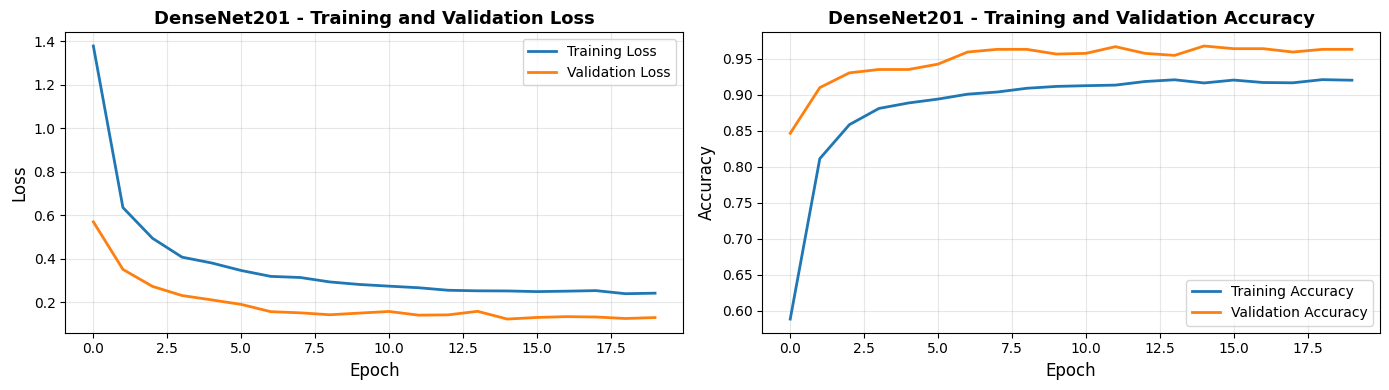

In [14]:

def plot_training_history(history, model_name):
    """Plot training and validation loss/accuracy"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f'{model_name} - Training and Validation Loss', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title(f'{model_name} - Training and Validation Accuracy', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name}_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "="*70)
print("Plotting Training History...")
print("="*70)

# Plot history for DenseNet201
plot_training_history(densenet_history, 'DenseNet201')

In [15]:
# Get predictions
def get_predictions(model, test_gen):
    """Generate predictions for test dataset"""
    predictions = model.predict(test_gen)
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = test_gen.classes
    return pred_classes, true_classes, predictions

densenet_pred, densenet_true, densenet_probs = None, None, None

# Get predictions for DenseNet201

densenet_pred, densenet_true, densenet_probs = get_predictions(densenet_model, test_generator)

69/69 ━━━━━━━━━━━━━━━━━━━━ 425s 6s/step


In [16]:
def compute_metrics(y_true, y_pred, model_name):
    """Compute and return evaluation metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    return metrics

# Compute metrics for DenseNet201
densenet_metrics = None

print("\n" + "="*70)
print("Computing Metrics...")
print("="*70)

# Ensure densenet_true and densenet_pred exist from the previous step
if 'densenet_true' in locals() and 'densenet_pred' in locals():
    densenet_metrics = compute_metrics(densenet_true, densenet_pred, 'DenseNet201')
else:
    print("Warning: Predictions (densenet_true, densenet_pred) not found. Make sure to run predictions first.")

# Display metrics comparison
print("\nPRE-TRAINED MODELS PERFORMANCE METRICS")

metrics_list = []
if densenet_metrics is not None:
    metrics_list.append([
        densenet_metrics['Model'],
        f"{densenet_metrics['Accuracy']:.4f}",
        f"{densenet_metrics['Precision']:.4f}",
        f"{densenet_metrics['Recall']:.4f}",
        f"{densenet_metrics['F1-Score']:.4f}"
    ])

metrics_arr = np.array(metrics_list)

if len(metrics_arr) > 0:
    print(f"{'Model':<20} {'Accuracy':<15} {'Precision':<15} {'Recall':<15} {'F1-Score':<15}")
    print("-" * 80)
    for row in metrics_arr:
        print(f"{row[0]:<20} {row[1]:<15} {row[2]:<15} {row[3]:<15} {row[4]:<15}")
else:
    print("No metrics to display.")



Computing Metrics...

PRE-TRAINED MODELS PERFORMANCE METRICS
Model                Accuracy        Precision       Recall          F1-Score       
--------------------------------------------------------------------------------
DenseNet201          0.9574          0.9566          0.9560          0.9557         


Generating Confusion Matrix...


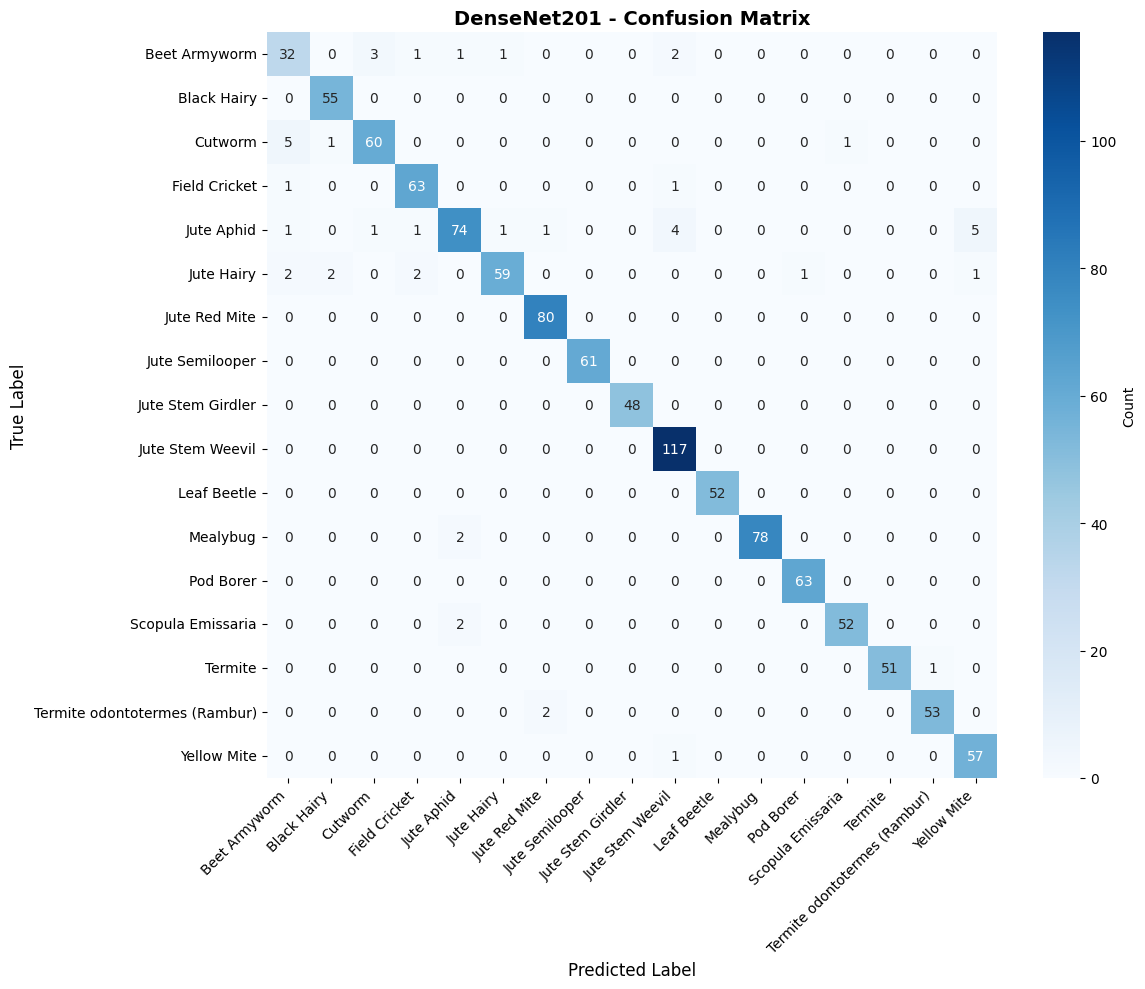



DenseNet201 Classification Report:
                               precision    recall  f1-score   support

                Beet Armyworm       0.78      0.80      0.79        40
                  Black Hairy       0.95      1.00      0.97        55
                      Cutworm       0.94      0.90      0.92        67
                Field Cricket       0.94      0.97      0.95        65
                   Jute Aphid       0.94      0.84      0.89        88
                   Jute Hairy       0.97      0.88      0.92        67
                Jute Red Mite       0.96      1.00      0.98        80
              Jute Semilooper       1.00      1.00      1.00        61
            Jute Stem Girdler       1.00      1.00      1.00        48
             Jute Stem Weevil       0.94      1.00      0.97       117
                  Leaf Beetle       1.00      1.00      1.00        52
                     Mealybug       1.00      0.97      0.99        80
                    Pod Borer       0.9

In [17]:

def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, cbar_kws={'label': 'Count'})
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

# Ensure class_names and predictions are available from previous steps
if 'train_generator' in locals() and 'densenet_true' in locals() and 'densenet_pred' in locals():
    class_names = list(train_generator.class_indices.keys())

    print("Generating Confusion Matrix...")

    # Plot for DenseNet201
    plot_confusion_matrix(densenet_true, densenet_pred, 'DenseNet201', class_names)

    print("\n\nDenseNet201 Classification Report:")
    print(classification_report(densenet_true, densenet_pred, target_names=class_names, zero_division=0))

else:
    print("Error: Required variables (train_generator, densenet_true, densenet_pred) not found.")


Plotting Metrics Comparison...


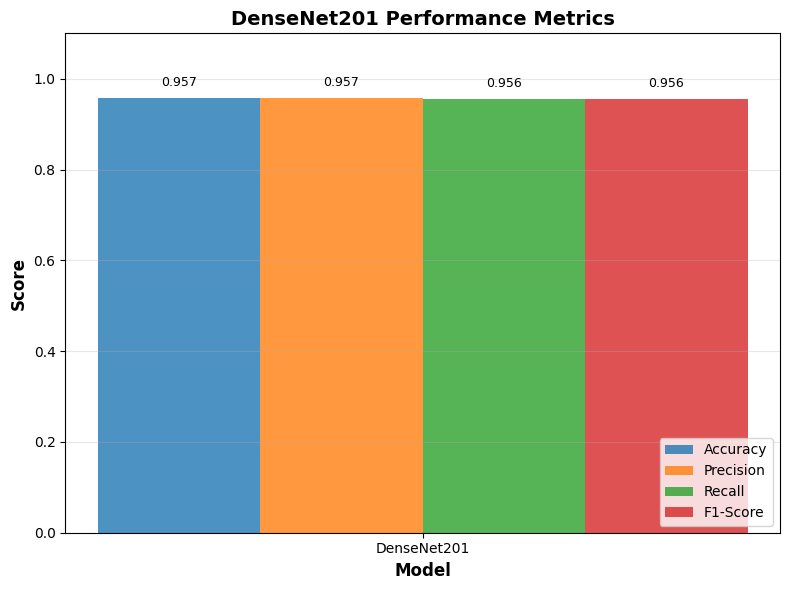

In [18]:

def plot_metrics_comparison():
    """Plot comparison of metrics (Adapted for DenseNet201)"""

    # Check if metrics are available (assuming densenet_metrics is in the global scope from previous steps)
    if 'densenet_metrics' not in globals() or densenet_metrics is None:
        print("No metrics available to plot. Please run the evaluation step first.")
        return

    models = []
    accuracy = []
    precision = []
    recall = []
    f1 = []

    # Add DenseNet201 data
    models.append('DenseNet201')
    accuracy.append(densenet_metrics['Accuracy'])
    precision.append(densenet_metrics['Precision'])
    recall.append(densenet_metrics['Recall'])
    f1.append(densenet_metrics['F1-Score'])

    x = np.arange(len(models))
    width = 0.2

    plt.figure(figsize=(8, 6)) # Adjusted width since we only have one model
    plt.bar(x - 1.5*width, accuracy, width, label='Accuracy', alpha=0.8)
    plt.bar(x - 0.5*width, precision, width, label='Precision', alpha=0.8)
    plt.bar(x + 0.5*width, recall, width, label='Recall', alpha=0.8)
    plt.bar(x + 1.5*width, f1, width, label='F1-Score', alpha=0.8)

    plt.xlabel('Model', fontsize=12, fontweight='bold')
    plt.ylabel('Score', fontsize=12, fontweight='bold')
    plt.title('DenseNet201 Performance Metrics', fontsize=14, fontweight='bold')
    plt.xticks(x, models)
    plt.legend(loc='lower right')
    plt.ylim([0, 1.1])
    plt.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i in range(len(models)):
        plt.text(i - 1.5*width, accuracy[i] + 0.02, f'{accuracy[i]:.3f}', ha='center', va='bottom', fontsize=9)
        plt.text(i - 0.5*width, precision[i] + 0.02, f'{precision[i]:.3f}', ha='center', va='bottom', fontsize=9)
        plt.text(i + 0.5*width, recall[i] + 0.02, f'{recall[i]:.3f}', ha='center', va='bottom', fontsize=9)
        plt.text(i + 1.5*width, f1[i] + 0.02, f'{f1[i]:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "="*70)
print("Plotting Metrics Comparison...")
print("="*70)

plot_metrics_comparison()
